In [ ]:
%matplotlib inline
from pathlib import Path
from typing import Dict, List, Tuple
import os
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision.transforms import v2

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())


torch version: 2.11.0+cpu
torchvision version: 0.26.0+cpu
cuda available: False


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
  torch.backends.cudnn.benchmark = False
  torch.backends.cudnn.deterministic = True


def get_default_device() -> torch.device:
  if hasattr(torch, "accelerator") and torch.accelerator.is_available():
    return torch.device(torch.accelerator.current_accelerator().type)
  if torch.cuda.is_available():
    return torch.device("cuda")
  if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    return torch.device("mps")
  return torch.device("cpu")

device = get_default_device()
NUM_WORKERS = 0 if os.name == "nt" else 2
PIN_MEMORY = device.type == "cuda"


print("seed:", SEED)
print("selected device:", device)
print("num_workers:", NUM_WORKERS)
print("pin_memory:", PIN_MEMORY)


seed: 42
selected device: cpu
num_workers: 2
pin_memory: False


DataLoader
- index 기반으로 샘플 1개와 label 1개를 반환
- Dataset 위에 sampler, batching, multiprocessing worker를 결합 -> 학습 루프에서 순회 가능한 mini-batch stream을 생성


In [ ]:
DATA_DIR = Path("./data")
BATCH_SIZE = 64

FASHIONMNIST_MEAN = (0.5, 0.5, 0.5)
FASHIONMNIST_STD = (0.5, 0.5, 0.5)

transform = v2.Compose([
    v2.Resize((32,32)),
    v2.Grayscale(num_output_channels=3),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(FASHIONMNIST_MEAN, FASHIONMNIST_STD),
])

dataset_start_time = time.perf_counter()

trainset = torchvision.datasets.FashionMNIST(
  root=str(DATA_DIR),
  train=True,
  download=True,
  transform=transform,
)

testset = torchvision.datasets.FashionMNIST(
  root=str(DATA_DIR),
  train=False,
  download=True,
  transform=transform,
)

dataset_elapsed = time.perf_counter() - dataset_start_time

loader_generator = torch.Generator().manual_seed(SEED)

trainloader = torch.utils.data.DataLoader(
  trainset,
  batch_size=BATCH_SIZE,
  shuffle=True,
  num_workers=NUM_WORKERS,
  pin_memory=PIN_MEMORY,
  generator=loader_generator,
)

testloader = torch.utils.data.DataLoader(
  testset,
  batch_size=BATCH_SIZE,
  shuffle=False,
  num_workers=NUM_WORKERS,
  pin_memory=PIN_MEMORY,
)

classes = tuple(trainset.classes)

print("dataset load/download seconds:", round(dataset_elapsed, 2))
print("batch_size:", BATCH_SIZE)
print("classes:", classes)
print("train batches:", len(trainloader))
print("test batches:", len(testloader))



100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.82MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 56.9MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.3MB/s]


dataset load/download seconds: 1.53
batch_size: 64
classes: ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')
train batches: 938
test batches: 157


원본 28 * 28을 2 * 32 * 32로 변환

In [ ]:
print("trainset size:", len(trainset))
print("testset size:", len(testset))

sample_image, sample_label = trainset[0]

print("single image shape:", tuple(sample_image.shape))
print("single image dtype:", sample_image.dtype)
print("single label index:", sample_label)
print("single label name:", classes[sample_label])

train_targets = torch.as_tensor(trainset.targets, dtype=torch.long)
test_targets = torch.as_tensor(testset.targets, dtype=torch.long)
train_counts = torch.bincount(train_targets, minlength=len(classes))
test_counts = torch.bincount(test_targets, minlength=len(classes))

print("\nclass distribution")
for idx, name in enumerate(classes):
  print(f"{idx:2d} | {name:12s} | train={int(train_counts[idx]):5d} | test={int(test_counts[idx]):4d}")
assert len(trainset) == 60_000
assert len(testset) == 10_000
assert tuple(sample_image.shape) == (3, 32, 32)
assert len(classes) == 10



trainset size: 60000
testset size: 10000
single image shape: (3, 32, 32)
single image dtype: torch.float32
single label index: 9
single label name: Ankle boot

class distribution
 0 | T-shirt/top  | train= 6000 | test=1000
 1 | Trouser      | train= 6000 | test=1000
 2 | Pullover     | train= 6000 | test=1000
 3 | Dress        | train= 6000 | test=1000
 4 | Coat         | train= 6000 | test=1000
 5 | Sandal       | train= 6000 | test=1000
 6 | Shirt        | train= 6000 | test=1000
 7 | Sneaker      | train= 6000 | test=1000
 8 | Bag          | train= 6000 | test=1000
 9 | Ankle boot   | train= 6000 | test=1000


In [ ]:
raw_transform = v2.Compose([
  v2.Resize((32, 32)),
  v2.Grayscale(num_output_channels=3),
  v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True),
])

raw_trainset = torchvision.datasets.FashionMNIST(
  root=str(DATA_DIR),
  train=True,
  download=True,
  transform=raw_transform,
)

raw_loader = torch.utils.data.DataLoader(
  raw_trainset,
  batch_size=512,
  shuffle=False,
  num_workers=NUM_WORKERS,
  pin_memory=False,
)

def compute_channel_statistics(loader: torch.utils.data.DataLoader) -> Tuple[torch.Tensor, torch.Tensor]:
  channel_sum = torch.zeros(3)
  channel_squared_sum = torch.zeros(3)
  pixel_count = 0

  for images, _ in loader:
    channel_sum += images.sum(dim=(0, 2, 3))
    channel_squared_sum += (images ** 2).sum(dim=(0, 2, 3))
    pixel_count += images.size(0) * images.size(2) * images.size(3)

  mean = channel_sum / pixel_count
  std = (channel_squared_sum / pixel_count - mean ** 2).sqrt()
  return mean, std


estimated_mean, estimated_std = compute_channel_statistics(raw_loader)
print("estimated FashionMNIST train mean:", [round(v, 4) for v in estimated_mean.tolist()])
print("estimated FashionMNIST train std :", [round(v, 4) for v in estimated_std.tolist()])
print("tutorial mean:", FASHIONMNIST_MEAN)
print("tutorial std :", FASHIONMNIST_STD)



estimated FashionMNIST train mean: [0.2856, 0.2856, 0.2856]
estimated FashionMNIST train std : [0.3385, 0.3385, 0.3385]
tutorial mean: (0.5, 0.5, 0.5)
tutorial std : (0.5, 0.5, 0.5)


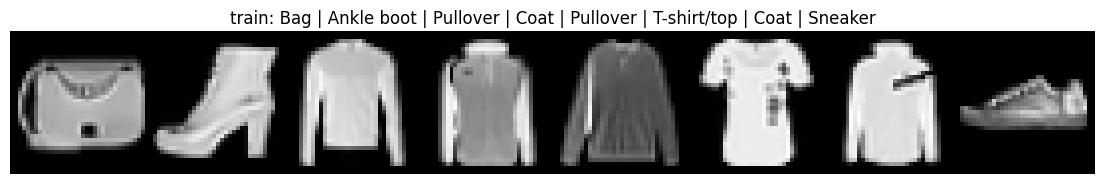

mini-batch image shape: (64, 3, 32, 32)
mini-batch label shape: (64,)
first labels: [8, 9, 2, 4, 2, 0, 4, 7]


In [ ]:
def denormalize(images: torch.Tensor,
                mean: Tuple[float, float, float] = FASHIONMNIST_MEAN,
                std: Tuple[float, float, float] = FASHIONMNIST_STD) -> torch.Tensor:
    if images.ndim == 3:
      mean_tensor = torch.tensor(mean, dtype=images.dtype, device=images.device).view(3, 1, 1)
      std_tensor = torch.tensor(std, dtype=images.dtype, device=images.device).view(3, 1, 1)
    elif images.ndim == 4:
      mean_tensor = torch.tensor(mean, dtype=images.dtype, device=images.device).view(1, 3, 1, 1)
      std_tensor = torch.tensor(std, dtype=images.dtype, device=images.device).view(1, 3, 1, 1)
    else:
      raise ValueError(f"expected 3D or 4D tensor, got shape {tuple(images.shape)}")
    return images * std_tensor + mean_tensor


def show_image_batch(images: torch.Tensor,
                     labels: torch.Tensor,
                     n: int = 8,
                     title_prefix: str = "labels") -> None:
    images = images[:n].detach().cpu()
    labels = labels[:n].detach().cpu()

    grid = torchvision.utils.make_grid(denormalize(images).clamp(0, 1), nrow=n)
    np_grid = grid.numpy().transpose((1, 2, 0))
    label_text = " | ".join(classes[int(label)] for label in labels)

    plt.figure(figsize=(14, 3))
    plt.imshow(np_grid)
    plt.axis("off")
    plt.title(f"{title_prefix}: {label_text}")
    plt.show()


train_images, train_labels = next(iter(trainloader))
show_image_batch(train_images, train_labels, n=8, title_prefix="train")

print("mini-batch image shape:", tuple(train_images.shape))
print("mini-batch label shape:", tuple(train_labels.shape))
print("first labels:", train_labels[:8].tolist())


데이터 변환
- conv1: 32 -> 28
- pooling: 28 -> 14
- conv2: 14 -> 10
- pooling: 10 -> 5
> 최종 out_channels가 16이기 때문에 (16 * 5 * 5)가 피처로 나옴
다음으로 Linear 처리

In [ ]:
class FashionMNISTNet(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
    self.fc1 = nn.Linear(in_features=16 * 5 * 5, out_features=120)
    self.fc2 = nn.Linear(in_features=120, out_features=84)
    self.fc3 = nn.Linear(in_features=84, out_features=10)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x, start_dim=1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

net = FashionMNISTNet().to(device)
print(net)


FashionMNISTNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [ ]:
def count_trainable_parameters(model: nn.Module) -> int:
  return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print("trainable parameters:", count_trainable_parameters(net))

x = train_images[:4].to(device)
with torch.inference_mode():
    print("input :", tuple(x.shape))
    x = net.conv1(x)
    print("conv1 :", tuple(x.shape))
    x = F.relu(x)
    print("relu1 :", tuple(x.shape))
    x = net.pool(x)
    print("pool1 :", tuple(x.shape))
    x = net.conv2(x)
    print("conv2 :", tuple(x.shape))
    x = F.relu(x)
    print("relu2 :", tuple(x.shape))
    x = net.pool(x)
    print("pool2 :", tuple(x.shape))
    x = torch.flatten(x, start_dim=1)
    print("flatten :", tuple(x.shape))
    x = F.relu(net.fc1(x))
    print("fc1 + relu :", tuple(x.shape))
    x = F.relu(net.fc2(x))
    print("fc2 + relu :", tuple(x.shape))
    x = net.fc3(x)
    print("logits :", tuple(x.shape))

trainable parameters: 62006
input : (4, 3, 32, 32)
conv1 : (4, 6, 28, 28)
relu1 : (4, 6, 28, 28)
pool1 : (4, 6, 14, 14)
conv2 : (4, 16, 10, 10)
relu2 : (4, 16, 10, 10)
pool2 : (4, 16, 5, 5)
flatten : (4, 400)
fc1 + relu : (4, 120)
fc2 + relu : (4, 84)
logits : (4, 10)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

net.eval()
with torch.inference_mode():
  demo_inputs = train_images[:4].to(device)
  demo_labels = train_labels[:4].to(device)
  demo_outputs = net(demo_inputs)
  demo_loss = criterion(demo_outputs, demo_labels)
  demo_probabilities = torch.softmax(demo_outputs, dim=1)

print("demo logits shape:", tuple(demo_outputs.shape))
print("demo labels shape:", tuple(demo_labels.shape))
print("demo loss:", float(demo_loss.item()))
print("softmax row sums:", [round(float(v), 4) for v in demo_probabilities.sum(dim=1).detach().cpu()])


demo logits shape: (4, 10)
demo labels shape: (4,)
demo loss: 2.296968698501587
softmax row sums: [1.0, 1.0, 1.0, 1.0]


In [ ]:
def train_one_epoch(model: nn.Module,
                    dataloader: torch.utils.data.DataLoader,
                    loss_fn: nn.Module,
                    optimizer: optim.Optimizer,
                    device: torch.device,
                    epoch: int,
                    log_interval: int = 100) -> Dict[str, float]:

  model.train()
  batch_losses: List[float] = []
  running_loss = 0.0
  correct = 0
  total = 0
  start_time = time.perf_counter()

  for batch_idx, (inputs, labels) in enumerate(dataloader, start=1):
      inputs = inputs.to(device, non_blocking=PIN_MEMORY)
      labels = labels.to(device, non_blocking=PIN_MEMORY)

      optimizer.zero_grad(set_to_none=True)
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      batch_loss = float(loss.item())
      batch_losses.append(batch_loss)
      running_loss += batch_loss

      predictions = outputs.argmax(dim=1)
      correct += int((predictions == labels).sum().item())
      total += int(labels.size(0))

      if batch_idx % log_interval == 0:
        print(f"epoch={epoch:02d} | batch={batch_idx:04d}/{len(dataloader):04d} | mean_loss={running_loss / log_interval:.4f}")
        running_loss = 0.0
  elapsed = time.perf_counter() - start_time
  return {
      "loss": float(np.mean(batch_losses)),
      "accuracy": 100.0 * correct / max(total, 1),
      "seconds": elapsed,
      }


@torch.inference_mode()
def evaluate(model: nn.Module,
             dataloader: torch.utils.data.DataLoader,
             loss_fn: nn.Module,
             device: torch.device) -> Dict[str, object]:
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    confusion = torch.zeros(len(classes), len(classes), dtype=torch.int64)

    for inputs, labels in dataloader:
      inputs = inputs.to(device, non_blocking=PIN_MEMORY)
      labels = labels.to(device, non_blocking=PIN_MEMORY)
      outputs = model(inputs)

      loss = loss_fn(outputs, labels)
      predictions = outputs.argmax(dim=1)
      batch_size = int(labels.size(0))

      total_loss += float(loss.item()) * batch_size
      correct += int((predictions == labels).sum().item())
      total += batch_size

      for true_label, predicted_label in zip(labels.detach().cpu(), predictions.detach().cpu()):
          confusion[int(true_label), int(predicted_label)] += 1

    return {
      "loss": total_loss / max(total, 1),
      "accuracy": 100.0 * correct / max(total, 1),
      "confusion": confusion,
    }

표시되는 값 -> mini 배치 평균 손실의 이동 기록
> epoch 종료 후에는 train accuracy와 test accuracy를 함께 기록


In [ ]:
EPOCHS = 20
LOG_INTERVAL = 100

history: Dict[str, List[float]] = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
}


for epoch in range(1, EPOCHS + 1):
  train_metrics = train_one_epoch(
      model=net,
      dataloader=trainloader,
      loss_fn=criterion,
      optimizer=optimizer,
      device=device,
      epoch=epoch,
      log_interval=LOG_INTERVAL,
  )
  test_metrics = evaluate(net, testloader, criterion, device)
  history["epoch"].append(epoch)
  history["train_loss"].append(float(train_metrics["loss"]))
  history["train_accuracy"].append(float(train_metrics["accuracy"]))
  history["test_loss"].append(float(test_metrics["loss"]))
  history["test_accuracy"].append(float(test_metrics["accuracy"]))

  print(
      f"epoch={epoch:02d} | "
      f"train_loss={train_metrics['loss']:.4f} | "
      f"train_acc={train_metrics['accuracy']:.2f}% | "
      f"test_loss={test_metrics['loss']:.4f} | "
      f"test_acc={test_metrics['accuracy']:.2f}% | "
      f"time={train_metrics['seconds']:.1f}s"
    )

print("training finished")

epoch=01 | batch=0100/0938 | mean_loss=2.2969
epoch=01 | batch=0200/0938 | mean_loss=2.2609
epoch=01 | batch=0300/0938 | mean_loss=2.0547
epoch=01 | batch=0400/0938 | mean_loss=1.2077
epoch=01 | batch=0500/0938 | mean_loss=0.8485
epoch=01 | batch=0600/0938 | mean_loss=0.7850
epoch=01 | batch=0700/0938 | mean_loss=0.7049
epoch=01 | batch=0800/0938 | mean_loss=0.6954
epoch=01 | batch=0900/0938 | mean_loss=0.6641
epoch=01 | train_loss=1.2536 | train_acc=55.87% | test_loss=0.6580 | test_acc=74.56% | time=44.9s
epoch=02 | batch=0100/0938 | mean_loss=0.6450
epoch=02 | batch=0200/0938 | mean_loss=0.6194
epoch=02 | batch=0300/0938 | mean_loss=0.5974
epoch=02 | batch=0400/0938 | mean_loss=0.5908
epoch=02 | batch=0500/0938 | mean_loss=0.5807
epoch=02 | batch=0600/0938 | mean_loss=0.5785
epoch=02 | batch=0700/0938 | mean_loss=0.5678
epoch=02 | batch=0800/0938 | mean_loss=0.5424
epoch=02 | batch=0900/0938 | mean_loss=0.5325
epoch=02 | train_loss=0.5816 | train_acc=77.79% | test_loss=0.5566 | test_

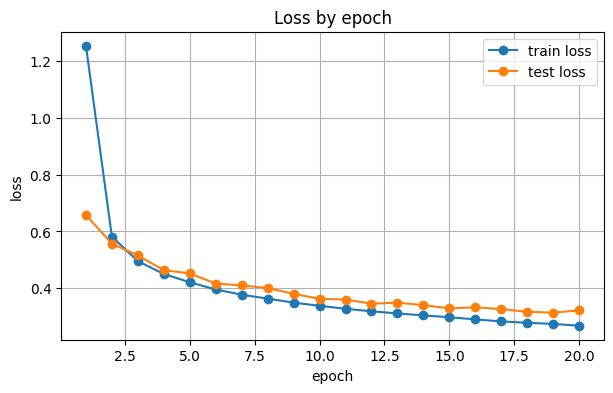

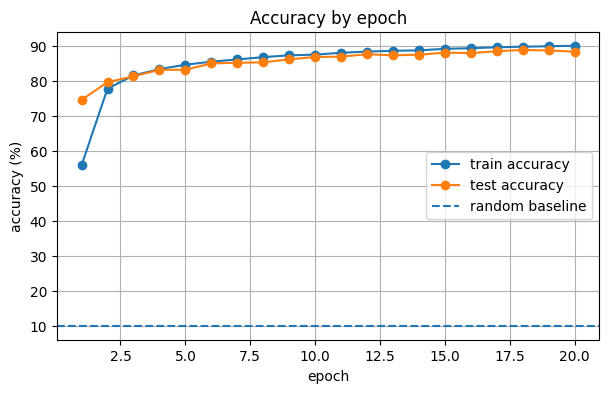

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="train loss")
plt.plot(history["epoch"], history["test_loss"], marker="o", label="test loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss by epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["epoch"], history["train_accuracy"], marker="o", label="train accuracy")
plt.plot(history["epoch"], history["test_accuracy"], marker="o", label="test accuracy")
plt.axhline(100 / len(classes), linestyle="--", label="random baseline")
plt.xlabel("epoch")
plt.ylabel("accuracy (%)")
plt.title("Accuracy by epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
MODEL_PATH = Path("./fashionmnist_cnn_state_dict.pt")
torch.save(net.state_dict(), MODEL_PATH)
print("saved model path:", MODEL_PATH.resolve())
print("saved file size MB:", round(MODEL_PATH.stat().st_size / (1024 ** 2), 4))

reloaded_net = FashionMNISTNet().to(device)
try:
  state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
except TypeError:
  state_dict = torch.load(MODEL_PATH, map_location=device)


load_result = reloaded_net.load_state_dict(state_dict)
reloaded_net.eval()

print("load result:", load_result)
reloaded_metrics = evaluate(reloaded_net, testloader, criterion, device)
print(f"reloaded test accuracy: {reloaded_metrics['accuracy']:.2f}%")


saved model path: /content/fashionmnist_cnn_state_dict.pt
saved file size MB: 0.2407
load result: <All keys matched successfully>
reloaded test accuracy: 88.34%


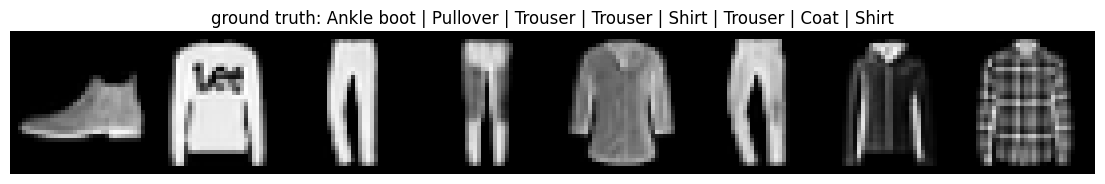

prediction results
sample=00 | true=Ankle boot | pred=Ankle boot | confidence=0.958 | correct
sample=01 | true=Pullover   | pred=Pullover   | confidence=0.999 | correct
sample=02 | true=Trouser    | pred=Trouser    | confidence=1.000 | correct
sample=03 | true=Trouser    | pred=Trouser    | confidence=1.000 | correct
sample=04 | true=Shirt      | pred=Shirt      | confidence=0.637 | correct
sample=05 | true=Trouser    | pred=Trouser    | confidence=0.998 | correct
sample=06 | true=Coat       | pred=Coat       | confidence=0.955 | correct
sample=07 | true=Shirt      | pred=Shirt      | confidence=0.536 | correct


In [ ]:
test_images, test_labels = next(iter(testloader))
show_image_batch(test_images, test_labels, n=8, title_prefix="ground truth")

reloaded_net.eval()
with torch.inference_mode():
  outputs = reloaded_net(test_images[:8].to(device, non_blocking=PIN_MEMORY))
  probabilities = torch.softmax(outputs, dim=1)
  predictions = outputs.argmax(dim=1).detach().cpu()
  confidences = probabilities.max(dim=1).values.detach().cpu()

print("prediction results")
for idx in range(8):
  true_name = classes[int(test_labels[idx])]
  pred_name = classes[int(predictions[idx])]
  confidence = float(confidences[idx])
  mark = "correct" if true_name == pred_name else "wrong"
  print(f"sample={idx:02d} | true={true_name:10s} | pred={pred_name:10s} | confidence={confidence:.3f} | {mark}")